送信側
送信文字列:
LFSR SYNC TEST

送信データビット:
0100110001000110010100110101001000100000010100110101100101001110010000110010000001010100010001010101001101010100

ペイロード長: 112 ビット
実際の同期開始位置: 98

同期捕捉結果
最大相関値: 0.6777
同期捕捉に成功しました。
推定同期開始位置: 98
実際の同期開始位置: 98
同期位置の誤差: 0
極性反転の検出: False

復号結果
送信文字列:
LFSR SYNC TEST

復号文字列:
L�Y`�SY_�8@G�

復号ビット列:
0100110011000111010110010110000010000000010100110101100101011111110000110011100001000000010001110001000110010100

総ビット数: 112
誤りビット数: 21
BER: 0.187500
正解率: 81.25%
誤り位置: [8, 15, 20, 22, 26, 27, 30, 32, 34, 59, 63, 64, 75, 76, 83, 85, 94, 97, 102, 104, 105]

ビットごとの比較
位置    0-  63
送信: 0100110001000110010100110101001000100000010100110101100101001110
復号: 0100110011000111010110010110000010000000010100110101100101011111
比較: ........X......X....X.X...XX..X.X.X........................X...X

位置   64- 111
送信: 010000110010000001010100010001010101001101010100
復号: 110000110011100001000000010001110001000110010100
比較: X..........XX......X.X........X..X....X.XX......



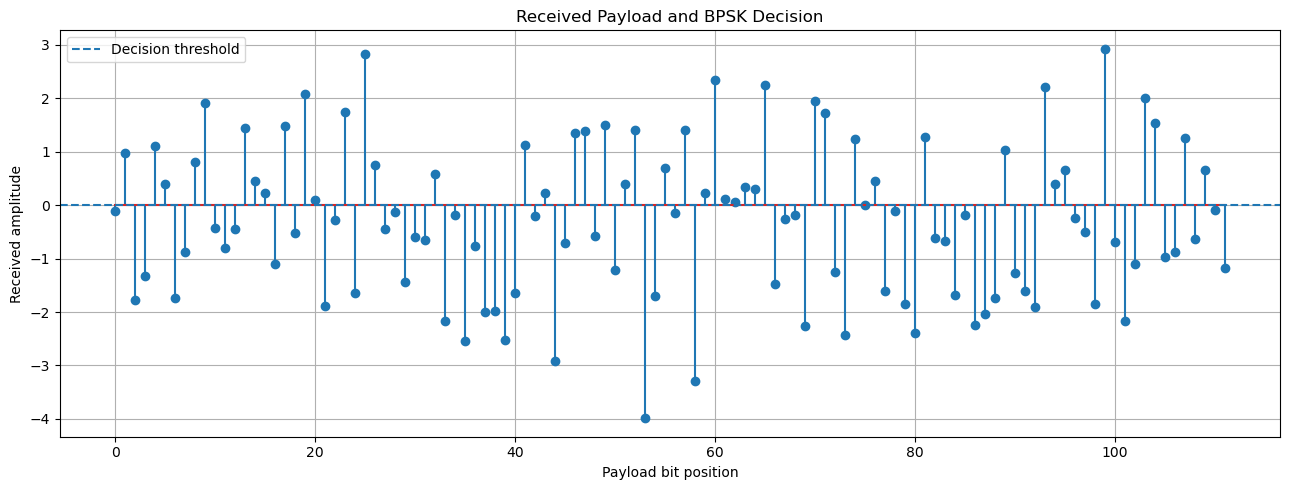

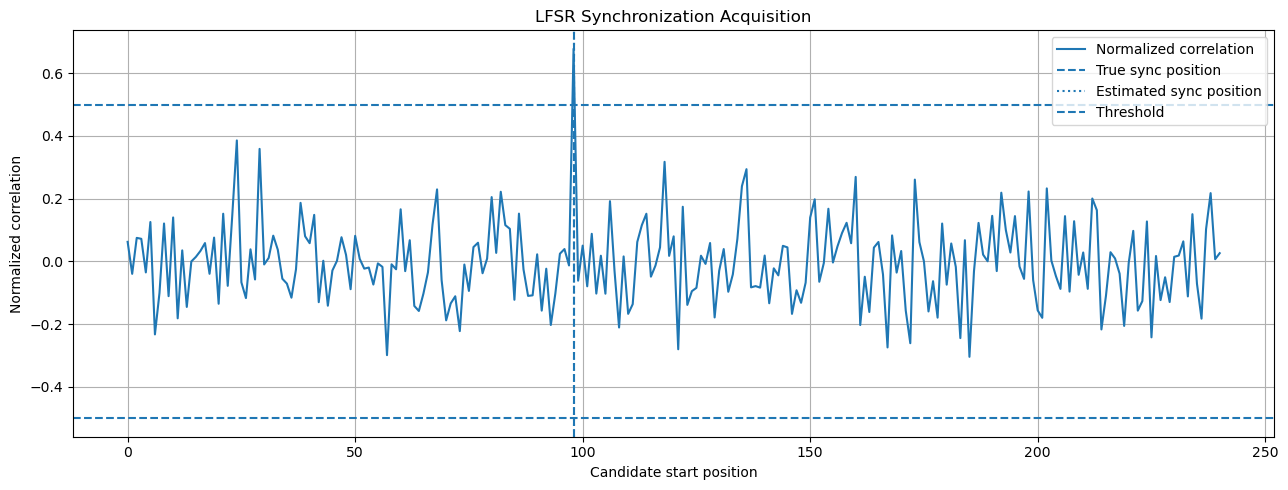

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LFSR系列の生成
# ============================================================

def generate_lfsr_sequence(initial_state, taps, length):
    """
    LFSRから0/1のPN系列を生成する。
    """

    state = list(initial_state)

    if not state:
        raise ValueError("初期状態を指定してください。")

    if all(bit == 0 for bit in state):
        raise ValueError("初期状態をすべて0にはできません。")

    if any(bit not in (0, 1) for bit in state):
        raise ValueError("初期状態は0と1だけで指定してください。")

    if any(tap < 0 or tap >= len(state) for tap in taps):
        raise ValueError("タップ位置が範囲外です。")

    sequence = []

    for _ in range(length):
        output_bit = state[-1]
        sequence.append(output_bit)

        feedback = 0

        for tap in taps:
            feedback ^= state[tap]

        state = [feedback] + state[:-1]

    return np.array(sequence, dtype=np.int8)


# ============================================================
# 2. 文字列とビット列の相互変換
# ============================================================

def text_to_bits(text):
    """
    ASCII文字列を8ビット単位のビット列へ変換する。

    例:
        "A"
        01000001
    """

    encoded = text.encode("ascii")

    bits = []

    for byte in encoded:
        for bit_position in range(7, -1, -1):
            bit = (byte >> bit_position) & 1
            bits.append(bit)

    return np.array(bits, dtype=np.int8)


def bits_to_text(bits, replace_errors=True):
    """
    8ビット単位のビット列をASCII文字列へ変換する。

    不正なASCIIコードが現れた場合は、
    replace_errors=Trueなら '?' に置換する。
    """

    bits = np.asarray(bits, dtype=np.int8)

    usable_length = len(bits) - len(bits) % 8
    bits = bits[:usable_length]

    decoded_bytes = bytearray()

    for start in range(0, usable_length, 8):
        byte_bits = bits[start:start + 8]

        value = 0

        for bit in byte_bits:
            value = (value << 1) | int(bit)

        decoded_bytes.append(value)

    if replace_errors:
        return decoded_bytes.decode(
            "ascii",
            errors="replace"
        )

    return decoded_bytes.decode("ascii")


# ============================================================
# 3. BPSK変調・復調
# ============================================================

def bits_to_bpsk(bits):
    """
    0 -> -1
    1 -> +1
    """

    return 2.0 * np.asarray(bits, dtype=float) - 1.0


def bpsk_to_bits(symbols):
    """
    受信振幅が0以上なら1、0未満なら0と判定する。
    """

    return (np.asarray(symbols) >= 0).astype(np.int8)


# ============================================================
# 4. 送信側
# ============================================================

def transmitter(
    message="LFSR SYNC TEST",
    sync_length=63,
    prefix_length=None,
    suffix_length=30,
    seed=1234
):
    """
    同期系列と文字列データを含む送信信号を生成する。
    """

    rng = np.random.default_rng(seed)

    # 6段LFSRのPN系列
    sync_bits = generate_lfsr_sequence(
        initial_state=[1, 0, 0, 0, 0, 1],
        taps=[0, 5],
        length=sync_length
    )

    # 文字列をビット列へ符号化
    payload_bits = text_to_bits(message)

    if prefix_length is None:
        prefix_length = int(rng.integers(30, 100))

    # 同期系列の前後にランダムなビット列を配置
    prefix_bits = rng.integers(
        0,
        2,
        size=prefix_length,
        dtype=np.int8
    )

    suffix_bits = rng.integers(
        0,
        2,
        size=suffix_length,
        dtype=np.int8
    )

    # フレーム
    frame_bits = np.concatenate([
        sync_bits,
        payload_bits
    ])

    # 受信機が観測する全系列
    transmitted_bits = np.concatenate([
        prefix_bits,
        frame_bits,
        suffix_bits
    ])

    transmitted_symbols = bits_to_bpsk(
        transmitted_bits
    )

    return {
        "message": message,
        "sync_bits": sync_bits,
        "payload_bits": payload_bits,
        "frame_bits": frame_bits,
        "transmitted_bits": transmitted_bits,
        "transmitted_symbols": transmitted_symbols,
        "true_sync_start": prefix_length
    }


# ============================================================
# 5. AWGN通信路
# ============================================================

def channel(
    transmitted_symbols,
    snr_db=0.0,
    polarity_inversion=False,
    seed=5678
):
    """
    BPSK信号へガウス雑音を加える。
    """

    rng = np.random.default_rng(seed)

    signal = np.asarray(
        transmitted_symbols,
        dtype=float
    ).copy()

    if polarity_inversion:
        signal *= -1.0

    signal_power = np.mean(signal ** 2)

    snr_linear = 10.0 ** (snr_db / 10.0)
    noise_power = signal_power / snr_linear
    noise_std = np.sqrt(noise_power)

    noise = rng.normal(
        0.0,
        noise_std,
        size=len(signal)
    )

    return signal + noise


# ============================================================
# 6. 正規化相関
# ============================================================

def normalized_correlation(received, reference):
    """
    受信信号の各位置と同期系列の正規化相関を計算する。
    """

    received = np.asarray(received, dtype=float)
    reference = np.asarray(reference, dtype=float)

    reference_length = len(reference)

    if len(received) < reference_length:
        raise ValueError(
            "受信信号が同期系列より短くなっています。"
        )

    result_length = (
        len(received) - reference_length + 1
    )

    correlations = np.zeros(result_length)

    reference_energy = np.sum(reference ** 2)

    for start in range(result_length):
        segment = received[
            start:start + reference_length
        ]

        segment_energy = np.sum(segment ** 2)

        denominator = np.sqrt(
            segment_energy * reference_energy
        )

        if denominator > 0:
            correlations[start] = (
                np.sum(segment * reference)
                / denominator
            )

    return correlations


# ============================================================
# 7. 受信側
# ============================================================

def receiver(
    received_symbols,
    sync_bits,
    payload_length,
    threshold=0.5,
    allow_polarity_inversion=True
):
    """
    同期捕捉後、データ部分を取り出して復調する。
    """

    sync_symbols = bits_to_bpsk(sync_bits)

    correlations = normalized_correlation(
        received_symbols,
        sync_symbols
    )

    if allow_polarity_inversion:
        estimated_sync_start = int(
            np.argmax(np.abs(correlations))
        )

        peak_correlation = correlations[
            estimated_sync_start
        ]

        detection_value = abs(peak_correlation)

    else:
        estimated_sync_start = int(
            np.argmax(correlations)
        )

        peak_correlation = correlations[
            estimated_sync_start
        ]

        detection_value = peak_correlation

    synchronized = detection_value >= threshold

    if not synchronized:
        return {
            "synchronized": False,
            "estimated_sync_start": None,
            "peak_correlation": peak_correlation,
            "correlations": correlations,
            "received_payload_symbols": None,
            "received_payload_bits": None,
            "decoded_text": None,
            "payload_start": None,
            "polarity_inverted": None
        }

    polarity_inverted = peak_correlation < 0

    payload_start = (
        estimated_sync_start + len(sync_bits)
    )

    payload_end = payload_start + payload_length

    if payload_end > len(received_symbols):
        raise ValueError(
            "同期位置以降のデータ長が不足しています。"
        )

    received_payload_symbols = received_symbols[
        payload_start:payload_end
    ].copy()

    # 相関ピークが負の場合は信号の極性を補正
    if polarity_inverted:
        received_payload_symbols *= -1.0

    received_payload_bits = bpsk_to_bits(
        received_payload_symbols
    )

    decoded_text = bits_to_text(
        received_payload_bits
    )

    return {
        "synchronized": True,
        "estimated_sync_start": estimated_sync_start,
        "peak_correlation": peak_correlation,
        "correlations": correlations,
        "received_payload_symbols": received_payload_symbols,
        "received_payload_bits": received_payload_bits,
        "decoded_text": decoded_text,
        "payload_start": payload_start,
        "polarity_inverted": polarity_inverted
    }


# ============================================================
# 8. 復号結果の評価
# ============================================================

def evaluate_decoding(
    transmitted_bits,
    decoded_bits
):
    """
    送信ビットと復号ビットを比較する。
    """

    transmitted_bits = np.asarray(
        transmitted_bits,
        dtype=np.int8
    )

    decoded_bits = np.asarray(
        decoded_bits,
        dtype=np.int8
    )

    if len(transmitted_bits) != len(decoded_bits):
        raise ValueError(
            "送信ビットと復号ビットの長さが異なります。"
        )

    error_mask = (
        transmitted_bits != decoded_bits
    )

    error_positions = np.where(
        error_mask
    )[0]

    error_count = len(error_positions)

    total_bits = len(transmitted_bits)

    ber = error_count / total_bits
    correct_rate = 1.0 - ber

    return {
        "error_mask": error_mask,
        "error_positions": error_positions,
        "error_count": error_count,
        "total_bits": total_bits,
        "ber": ber,
        "correct_rate": correct_rate
    }


def print_bit_comparison(
    transmitted_bits,
    decoded_bits,
    bits_per_line=64
):
    """
    送信ビットと復号ビットを行ごとに表示する。

    誤り位置はXで表示する。
    """

    transmitted_bits = np.asarray(transmitted_bits)
    decoded_bits = np.asarray(decoded_bits)

    for start in range(
        0,
        len(transmitted_bits),
        bits_per_line
    ):
        end = min(
            start + bits_per_line,
            len(transmitted_bits)
        )

        tx_part = transmitted_bits[start:end]
        rx_part = decoded_bits[start:end]

        tx_text = "".join(
            map(str, tx_part)
        )

        rx_text = "".join(
            map(str, rx_part)
        )

        comparison = "".join(
            "." if tx_bit == rx_bit else "X"
            for tx_bit, rx_bit
            in zip(tx_part, rx_part)
        )

        print(
            f"位置 {start:4d}-{end - 1:4d}"
        )
        print("送信:", tx_text)
        print("復号:", rx_text)
        print("比較:", comparison)
        print()


# ============================================================
# 9. メイン処理
# ============================================================

def main():

    # --------------------------------------------------------
    # 設定
    # --------------------------------------------------------

    transmitted_message = "LFSR SYNC TEST"

    sync_length = 63

    # 値を小さくすると雑音が強くなる
    snr_db = -1.0

    correlation_threshold = 0.5

    polarity_inversion = False

    # --------------------------------------------------------
    # 送信
    # --------------------------------------------------------

    tx = transmitter(
        message=transmitted_message,
        sync_length=sync_length,
        prefix_length=None,
        suffix_length=30,
        seed=1234
    )

    print("=" * 70)
    print("送信側")
    print("=" * 70)

    print("送信文字列:")
    print(tx["message"])

    print()
    print("送信データビット:")
    print(
        "".join(map(str, tx["payload_bits"]))
    )

    print()
    print(
        "ペイロード長:",
        len(tx["payload_bits"]),
        "ビット"
    )

    print(
        "実際の同期開始位置:",
        tx["true_sync_start"]
    )

    # --------------------------------------------------------
    # 通信路
    # --------------------------------------------------------

    received_symbols = channel(
        transmitted_symbols=tx[
            "transmitted_symbols"
        ],
        snr_db=snr_db,
        polarity_inversion=polarity_inversion,
        seed=5678
    )

    # --------------------------------------------------------
    # 受信と復号
    # --------------------------------------------------------

    rx = receiver(
        received_symbols=received_symbols,
        sync_bits=tx["sync_bits"],
        payload_length=len(tx["payload_bits"]),
        threshold=correlation_threshold,
        allow_polarity_inversion=True
    )

    print()
    print("=" * 70)
    print("同期捕捉結果")
    print("=" * 70)

    print(
        f"最大相関値: "
        f"{rx['peak_correlation']:.4f}"
    )

    if not rx["synchronized"]:
        print("同期捕捉に失敗しました。")
        return

    print("同期捕捉に成功しました。")

    print(
        "推定同期開始位置:",
        rx["estimated_sync_start"]
    )

    print(
        "実際の同期開始位置:",
        tx["true_sync_start"]
    )

    print(
        "同期位置の誤差:",
        rx["estimated_sync_start"]
        - tx["true_sync_start"]
    )

    print(
        "極性反転の検出:",
        rx["polarity_inverted"]
    )

    # --------------------------------------------------------
    # 復号評価
    # --------------------------------------------------------

    evaluation = evaluate_decoding(
        transmitted_bits=tx["payload_bits"],
        decoded_bits=rx["received_payload_bits"]
    )

    print()
    print("=" * 70)
    print("復号結果")
    print("=" * 70)

    print("送信文字列:")
    print(tx["message"])

    print()
    print("復号文字列:")
    print(rx["decoded_text"])

    print()
    print("復号ビット列:")
    print(
        "".join(
            map(
                str,
                rx["received_payload_bits"]
            )
        )
    )

    print()
    print("総ビット数:", evaluation["total_bits"])
    print("誤りビット数:", evaluation["error_count"])

    print(
        f"BER: {evaluation['ber']:.6f}"
    )

    print(
        f"正解率: "
        f"{evaluation['correct_rate'] * 100:.2f}%"
    )

    print(
        "誤り位置:",
        evaluation["error_positions"].tolist()
    )

    print()
    print("=" * 70)
    print("ビットごとの比較")
    print("=" * 70)

    print_bit_comparison(
        transmitted_bits=tx["payload_bits"],
        decoded_bits=rx["received_payload_bits"],
        bits_per_line=64
    )

    # --------------------------------------------------------
    # 復号振幅表示
    # --------------------------------------------------------

    payload_symbols = rx[
        "received_payload_symbols"
    ]

    plt.figure(figsize=(13, 5))

    plt.stem(
        np.arange(len(payload_symbols)),
        payload_symbols
    )

    plt.axhline(
        0,
        linestyle="--",
        label="Decision threshold"
    )

    plt.xlabel("Payload bit position")
    plt.ylabel("Received amplitude")
    plt.title(
        "Received Payload and BPSK Decision"
    )

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 相関波形
    # --------------------------------------------------------

    correlations = rx["correlations"]

    plt.figure(figsize=(13, 5))

    plt.plot(
        correlations,
        label="Normalized correlation"
    )

    plt.axvline(
        tx["true_sync_start"],
        linestyle="--",
        label="True sync position"
    )

    plt.axvline(
        rx["estimated_sync_start"],
        linestyle=":",
        label="Estimated sync position"
    )

    plt.axhline(
        correlation_threshold,
        linestyle="--",
        label="Threshold"
    )

    plt.axhline(
        -correlation_threshold,
        linestyle="--"
    )

    plt.xlabel("Candidate start position")
    plt.ylabel("Normalized correlation")
    plt.title("LFSR Synchronization Acquisition")

    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# 10. 実行
# ============================================================

if __name__ == "__main__":
    main()